# 🩹 Wound Classification - V3 (Best Performance)

## Improvements over V2:
- ✅ **Gradual Unfreezing** - Start frozen, then unfreeze for fine-tuning
- ✅ **Optimized Dropout** (0.4 instead of 0.5)
- ✅ **Two-Phase Training** - Phase 1: frozen backbone, Phase 2: full fine-tuning
- ✅ **Better Learning Rate Schedule**
- ✅ **Label Smoothing** - Helps generalization
- ✅ **Test Evaluation** included

**Target: 85-90% accuracy with no overfitting**

---

## Cell 1: Imports

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
from torchvision import transforms, datasets, models

# Check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   Running on CPU")

✅ Using device: cpu
   Running on CPU


## Cell 2: Configuration ⚙️

### 👇 EDIT SETTINGS HERE! 👇

In [ ]:
# =============================================================================
# ⚙️ CONFIGURATION V3 - EDIT HERE!
# =============================================================================

# 👇👇👇 TRAINING SETTINGS 👇👇👇
# Phase 1: Frozen backbone (fast learning of classifier)
PHASE1_EPOCHS = 15        # Epochs with frozen backbone
PHASE1_LR = 1e-3          # Higher LR for phase 1

# Phase 2: Full fine-tuning (slower, careful learning)
PHASE2_EPOCHS = 35        # Epochs with unfrozen backbone  
PHASE2_LR = 1e-5          # Much lower LR for fine-tuning

# Total epochs = PHASE1 + PHASE2 = 50

BATCH_SIZE = 32
DROPOUT_RATE = 0.4        # Slightly lower than V2 (was 0.5)
PATIENCE = 15             # Early stopping patience
LABEL_SMOOTHING = 0.1     # Helps prevent overconfidence
# 👆👆👆 TRAINING SETTINGS 👆👆👆

# Paths
CROPPED_DATA_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\cropped_classification_data"
MODEL_SAVE_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models"

# Image settings
IMAGE_SIZE = 224

# Create directories
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print("="*60)
print("⚙️ CONFIGURATION V3 (Two-Phase Training)")
print("="*60)
print(f"   Phase 1 (Frozen):     {PHASE1_EPOCHS} epochs @ LR={PHASE1_LR}")
print(f"   Phase 2 (Fine-tune):  {PHASE2_EPOCHS} epochs @ LR={PHASE2_LR}")
print(f"   Total Epochs:         {PHASE1_EPOCHS + PHASE2_EPOCHS}")
print(f"   Batch size:           {BATCH_SIZE}")
print(f"   Dropout:              {DROPOUT_RATE}")
print(f"   Label Smoothing:      {LABEL_SMOOTHING}")
print(f"   Early Stopping:       {PATIENCE} epochs")
print(f"   Device:               {DEVICE}")
print("="*60)

⚙️ CONFIGURATION V3 (Two-Phase Training)
   Phase 1 (Frozen):     15 epochs @ LR=0.001
   Phase 2 (Fine-tune):  35 epochs @ LR=1e-05
   Total Epochs:         50
   Batch size:           32
   Dropout:              0.4
   Label Smoothing:      0.1
   Early Stopping:       12 epochs
   Device:               cpu


## Cell 3: Data Transforms (Balanced Augmentation)

In [3]:
def get_train_transforms():
    """
    Balanced augmentation - strong enough to prevent overfitting,
    but not so strong that it hurts learning.
    """
    return transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMAGE_SIZE),
        
        # Flips
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        
        # Rotation
        transforms.RandomRotation(degrees=30),
        
        # Color augmentation (moderate)
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),
        
        # Affine transforms
        transforms.RandomAffine(
            degrees=10,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
        ),
        
        # To tensor and normalize
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        
        # Random erasing (moderate)
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    ])

def get_val_transforms():
    """Validation/Test transforms (no augmentation)."""
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

print("✅ Transforms defined (balanced augmentation)!")

✅ Transforms defined (balanced augmentation)!


## Cell 4: Load All Datasets

In [4]:
print("📂 Loading datasets...\n")

# Training data
train_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Train'),
    transform=get_train_transforms()
)

# Validation data
val_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Valid'),
    transform=get_val_transforms()
)

# Test data
test_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'test'),
    transform=get_val_transforms()
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Class distribution
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("="*60)
print("📊 DATASET SUMMARY")
print("="*60)
print(f"   Classes: {train_dataset.classes}")
print(f"")
print(f"   Training:    {len(train_dataset):,} images")
for cls_idx, cls_name in enumerate(train_dataset.classes):
    print(f"      - {cls_name}: {class_counts[cls_idx]:,}")
print(f"")
print(f"   Validation:  {len(val_dataset):,} images")
print(f"   Test:        {len(test_dataset):,} images")
print("="*60)

📂 Loading datasets...

📊 DATASET SUMMARY
   Classes: ['infected', 'non-infected']

   Training:    700 images
      - infected: 350
      - non-infected: 350

   Validation:  170 images
   Test:        152 images


## Cell 5: Create EfficientNet Model (V3)

In [5]:
class WoundClassifierV3(nn.Module):
    """
    EfficientNet-B0 with improved classifier head.
    Supports freezing/unfreezing backbone for two-phase training.
    """
    def __init__(self, num_classes=2, dropout_rate=0.4):
        super().__init__()
        
        # Load pretrained EfficientNet-B0
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = models.efficientnet_b0(weights=weights)
        
        # Get the number of features from backbone
        num_features = self.backbone.classifier[1].in_features
        
        # Remove original classifier
        self.backbone.classifier = nn.Identity()
        
        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(num_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(p=dropout_rate * 0.5),  # Less dropout in final layer
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        """Freeze all backbone layers."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("   🔒 Backbone FROZEN")
    
    def unfreeze_backbone(self):
        """Unfreeze all backbone layers for fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("   🔓 Backbone UNFROZEN for fine-tuning")
    
    def unfreeze_top_layers(self, num_blocks=3):
        """Unfreeze only the top N blocks of the backbone."""
        # First freeze everything
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Then unfreeze top blocks
        for param in self.backbone.features[-num_blocks:].parameters():
            param.requires_grad = True
        print(f"   🔓 Top {num_blocks} backbone blocks UNFROZEN")


# Create model
print("🏗️ Creating WoundClassifierV3 model...")
model = WoundClassifierV3(num_classes=2, dropout_rate=DROPOUT_RATE)
model = model.to(DEVICE)

# Start with frozen backbone
model.freeze_backbone()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model created!")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

🏗️ Creating WoundClassifierV3 model...
   🔒 Backbone FROZEN

✅ Model created!
   Total parameters:     4,730,622
   Trainable parameters: 723,074 (15.3%)


## Cell 6: Training Functions

In [6]:
class EarlyStopping:
    """Early stopping with patience."""
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0
        return self.early_stop
    
    def reset(self):
        """Reset early stopping for new phase."""
        self.counter = 0
        self.early_stop = False


def train_one_epoch(model, train_loader, criterion, optimizer, device, scaler, use_amp):
    """Train for one epoch."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        if use_amp:
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        total_loss += loss.item()
        
        if (batch_idx + 1) % 20 == 0:
            print(f"      Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {100.*correct/total:.1f}%")
    
    return total_loss / len(train_loader), 100. * correct / total


def validate(model, val_loader, criterion, device, use_amp):
    """Validate the model."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            total_loss += loss.item()
    
    return total_loss / len(val_loader), 100. * correct / total

print("✅ Training functions defined!")

✅ Training functions defined!


## Cell 7: Two-Phase Training Function

In [7]:
def train_two_phase(model, train_loader, val_loader, save_path):
    """
    Two-phase training:
    Phase 1: Train classifier only (frozen backbone)
    Phase 2: Fine-tune entire network (unfrozen backbone)
    """
    
    # Loss with label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    
    # Mixed precision
    use_amp = DEVICE.type == 'cuda'
    scaler = GradScaler('cuda') if use_amp else None
    
    # Early stopping
    early_stopping = EarlyStopping(patience=PATIENCE)
    
    # Track best model
    best_acc = 0.0
    best_model_state = None
    
    # History
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'phase': []}
    
    total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
    current_epoch = 0
    
    # =================================================================
    # PHASE 1: Train classifier only (frozen backbone)
    # =================================================================
    print(f"\n{'='*60}")
    print(f"🚀 PHASE 1: Training Classifier (Frozen Backbone)")
    print(f"   Epochs: {PHASE1_EPOCHS} | LR: {PHASE1_LR}")
    print(f"{'='*60}\n")
    
    model.freeze_backbone()
    
    # Optimizer for phase 1 (only classifier parameters)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=PHASE1_LR,
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS, eta_min=PHASE1_LR/10)
    
    for epoch in range(PHASE1_EPOCHS):
        current_epoch += 1
        print(f"\n📍 Epoch {current_epoch}/{total_epochs} [Phase 1]")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler, use_amp)
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE, use_amp)
        
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['phase'].append(1)
        
        gap = train_acc - val_acc
        gap_icon = "🟢" if gap < 5 else "🟡" if gap < 10 else "🔴"
        
        print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"   Gap:   {gap:.1f}% {gap_icon}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"   ✅ New best: {val_acc:.2f}%")
    
    # =================================================================
    # PHASE 2: Fine-tune entire network (unfrozen backbone)
    # =================================================================
    print(f"\n{'='*60}")
    print(f"🚀 PHASE 2: Fine-tuning Entire Network")
    print(f"   Epochs: {PHASE2_EPOCHS} | LR: {PHASE2_LR}")
    print(f"{'='*60}\n")
    
    # Unfreeze backbone
    model.unfreeze_backbone()
    
    # New optimizer with lower LR for fine-tuning
    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': PHASE2_LR},          # Lower LR for backbone
        {'params': model.classifier.parameters(), 'lr': PHASE2_LR * 10}    # Higher LR for classifier
    ], weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)
    
    # Reset early stopping for phase 2
    early_stopping.reset()
    
    for epoch in range(PHASE2_EPOCHS):
        current_epoch += 1
        print(f"\n📍 Epoch {current_epoch}/{total_epochs} [Phase 2]")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler, use_amp)
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE, use_amp)
        
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['phase'].append(2)
        
        gap = train_acc - val_acc
        gap_icon = "🟢" if gap < 5 else "🟡" if gap < 10 else "🔴"
        
        print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"   Gap:   {gap:.1f}% {gap_icon}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch': current_epoch,
                'model_state_dict': best_model_state,
                'val_acc': best_acc,
                'val_loss': val_loss,
            }, save_path)
            print(f"   ✅ New best: {val_acc:.2f}% (saved!)")
        
        # Early stopping check
        if early_stopping(val_acc):
            print(f"\n⚠️ Early stopping at epoch {current_epoch}")
            break
    
    # =================================================================
    # TRAINING COMPLETE
    # =================================================================
    print(f"\n{'='*60}")
    print(f"🏁 TRAINING COMPLETE!")
    print(f"{'='*60}")
    print(f"   Total epochs:    {current_epoch}")
    print(f"   Best Val Acc:    {best_acc:.2f}%")
    print(f"   Model saved to:  {save_path}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return history, best_acc

print("✅ Two-phase training function defined!")

✅ Two-phase training function defined!


---
# 🏃 Cell 8: START TRAINING!
---

In [8]:
# Path to save the model
model_save_path = os.path.join(MODEL_SAVE_DIR, 'classification_efficientnet_v3.pth')

# Train!
history, best_accuracy = train_two_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=model_save_path
)

print(f"\n🏆 Best Validation Accuracy: {best_accuracy:.2f}%")


🚀 PHASE 1: Training Classifier (Frozen Backbone)
   Epochs: 15 | LR: 0.001

   🔒 Backbone FROZEN

📍 Epoch 1/50 [Phase 1]
      Batch 20/21 | Loss: 0.5362 | Acc: 65.3%
   Train: Loss=0.6709, Acc=65.48%
   Val:   Loss=0.6097, Acc=77.06%
   Gap:   -11.6% 🟢
   ✅ New best: 77.06%

📍 Epoch 2/50 [Phase 1]
      Batch 20/21 | Loss: 0.5540 | Acc: 72.0%
   Train: Loss=0.5927, Acc=72.17%
   Val:   Loss=0.7259, Acc=71.76%
   Gap:   0.4% 🟢

📍 Epoch 3/50 [Phase 1]
      Batch 20/21 | Loss: 0.4321 | Acc: 70.8%
   Train: Loss=0.5861, Acc=70.98%
   Val:   Loss=0.6324, Acc=72.94%
   Gap:   -2.0% 🟢

📍 Epoch 4/50 [Phase 1]
      Batch 20/21 | Loss: 0.6063 | Acc: 76.6%
   Train: Loss=0.5435, Acc=76.04%
   Val:   Loss=0.5997, Acc=77.06%
   Gap:   -1.0% 🟢

📍 Epoch 5/50 [Phase 1]
      Batch 20/21 | Loss: 0.5807 | Acc: 74.2%
   Train: Loss=0.5570, Acc=74.70%
   Val:   Loss=0.6323, Acc=76.47%
   Gap:   -1.8% 🟢

📍 Epoch 6/50 [Phase 1]
      Batch 20/21 | Loss: 0.4518 | Acc: 75.6%
   Train: Loss=0.5502, Acc=75.

## Cell 9: Plot Training History

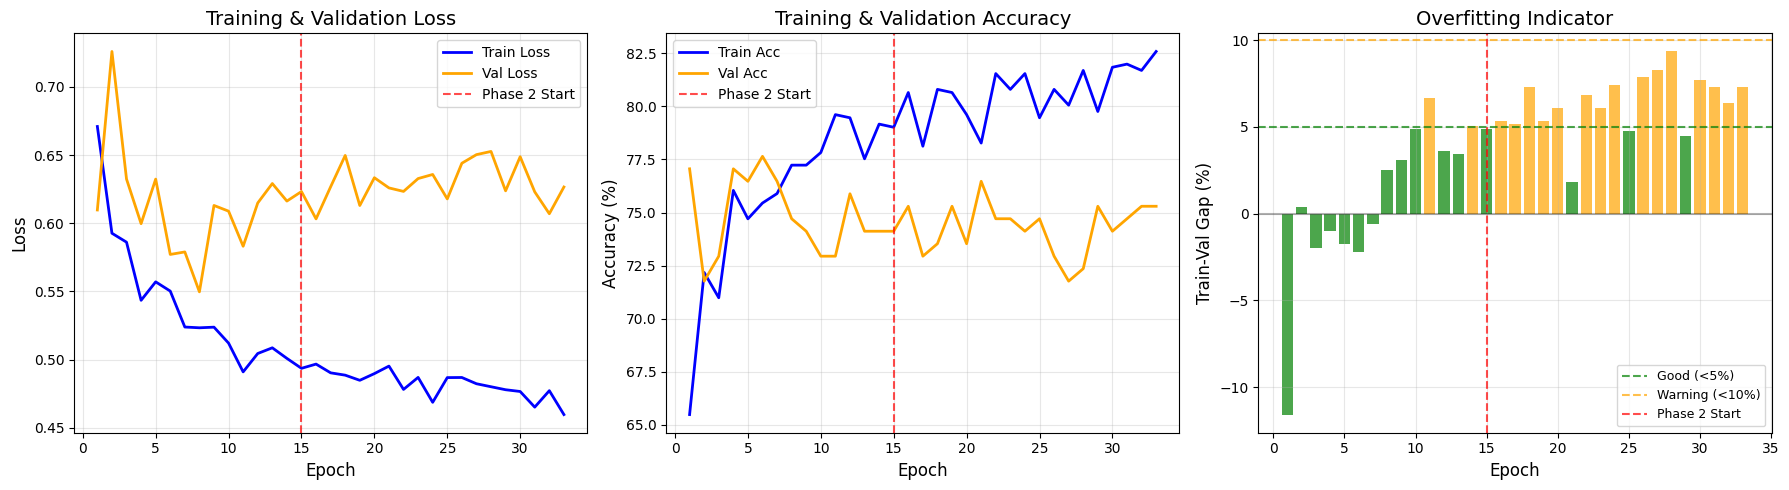

📊 Training history saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
phase_change = PHASE1_EPOCHS  # Where phase 2 starts

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'orange', label='Val Loss', linewidth=2)
axes[0].axvline(x=phase_change, color='red', linestyle='--', label='Phase 2 Start', alpha=0.7)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'orange', label='Val Acc', linewidth=2)
axes[1].axvline(x=phase_change, color='red', linestyle='--', label='Phase 2 Start', alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Gap plot
gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['green' if g < 5 else 'orange' if g < 10 else 'red' for g in gap]
axes[2].bar(epochs_range, gap, color=colors, alpha=0.7)
axes[2].axhline(y=5, color='green', linestyle='--', label='Good (<5%)', alpha=0.7)
axes[2].axhline(y=10, color='orange', linestyle='--', label='Warning (<10%)', alpha=0.7)
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].axvline(x=phase_change, color='red', linestyle='--', label='Phase 2 Start', alpha=0.7)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Train-Val Gap (%)', fontsize=12)
axes[2].set_title('Overfitting Indicator', fontsize=14)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Training history saved!")

In [25]:
pip install seaborn



SyntaxError: invalid syntax (2046479804.py, line 1)

---
# 🧪 Cell 10: TEST SET EVALUATION
---

In [28]:

try:
    from sklearn.metrics import classification_report, confusion_matrix
except ImportError:
    print("Installing scikit-learn...")
    !pip install seaborn
    from sklearn.metrics import classification_report, confusion_matrix


# Load best model
print("📂 Loading best model...")
checkpoint = torch.load(model_save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"   Loaded from epoch {checkpoint['epoch']}")
print(f"   Validation accuracy: {checkpoint['val_acc']:.2f}%")

# Evaluate on test set
print(f"\n🧪 Evaluating on TEST set ({len(test_dataset)} images)...")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate accuracy
test_accuracy = 100 * np.mean(all_preds == all_labels)

print(f"\n{'='*60}")
print(f"🧪 TEST SET RESULTS")
print(f"{'='*60}")
print(f"\n   🎯 TEST ACCURACY: {test_accuracy:.2f}%\n")

# Classification report
class_names = test_dataset.classes
print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 16})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix\nTest Accuracy: {test_accuracy:.2f}%', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix_v3.png'), dpi=150)
plt.show()

📂 Loading best model...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\PC\\Desktop\\GraduationProject\\MyProjectSTILL\\FirstTry\\outputs\\models\\classification_efficientnet_v3.pth'

---
# ✅ Cell 11: Final Summary
---

In [29]:
print("\n" + "="*60)
print("🏆 V3 FINAL SUMMARY")
print("="*60)

print(f"\n   📊 Training:")
print(f"      - Phase 1 (frozen):    {PHASE1_EPOCHS} epochs")
print(f"      - Phase 2 (fine-tune): {len(history['train_loss']) - PHASE1_EPOCHS} epochs")
print(f"      - Best Val Accuracy:   {best_accuracy:.2f}%")

print(f"\n   🧪 Test:")
print(f"      - Test Accuracy:       {test_accuracy:.2f}%")

print(f"\n   📁 Files:")
print(f"      - Model: classification_efficientnet_v3.pth")
print(f"      - History: training_history_v3.png")
print(f"      - Confusion Matrix: confusion_matrix_v3.png")

print("\n" + "="*60)

# Compare val and test
diff = abs(test_accuracy - best_accuracy)
if diff < 3:
    print("\n✅ Excellent! Test ≈ Validation - Model generalizes well!")
elif test_accuracy > best_accuracy:
    print("\n🎉 Great! Test > Validation - Model performs even better on new data!")
else:
    print(f"\n⚠️ Test is {diff:.1f}% lower than validation - slight overfitting remains.")


🏆 V3 FINAL SUMMARY

   📊 Training:
      - Phase 1 (frozen):    15 epochs
      - Phase 2 (fine-tune): 18 epochs
      - Best Val Accuracy:   77.65%

   🧪 Test:


NameError: name 'test_accuracy' is not defined

---
# 🔮 Cell 12: Predict Single Image
---

✅ Prediction function ready!

📝 Usage:


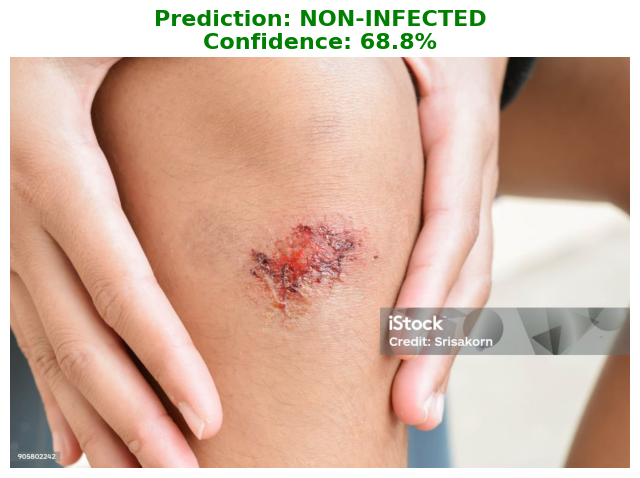


🩹 Result: NON-INFECTED
   Confidence: 68.8%
('non-infected', 0.6878275871276855)


In [32]:
def predict_wound(image_path):
    """Predict if wound is infected or not."""
    
    image = Image.open(image_path).convert('RGB')
    transform = get_val_transforms()
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    
    class_names = ['infected', 'non-infected']
    prediction = class_names[pred_class]
    
    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    color = 'red' if prediction == 'infected' else 'green'
    plt.title(f'Prediction: {prediction.upper()}\nConfidence: {confidence*100:.1f}%', 
              fontsize=16, fontweight='bold', color=color)
    plt.axis('off')
    plt.show()
    
    print(f"\n🩹 Result: {prediction.upper()}")
    print(f"   Confidence: {confidence*100:.1f}%")
    
    return prediction, confidence

print("✅ Prediction function ready!")
print("\n📝 Usage:")
print(   predict_wound(r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\TestPictureOutside\Screenshot 2026-02-16 175251.png"))